# Current-status CVLL shape across DGPs

This notebook compares the shape of CV incomplete log-likelihood (CVLL) against:

- PGD L1 constraint `M`
- FISTA penalty `lambda`

for **five different DGPs** under the same current-status censoring mechanism.

> Note: defaults are set to a moderate compute budget for interactive use. Increase grids / folds / iterations for final-quality curves.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from joblib import Parallel, delayed

from haldensity.censoring import (
    IntervalCensoredProjectedGDEstimator,
    IntervalCensoredFISTAEstimator,
    interval_censor_current_status_uniform,
)
from haldensity.censoring.interval.metrics import incomplete_loglik_interval
from haldensity.utils import TruncatedGMM, TruncatedNormal, Sinusoidal, StepFunction

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- Configuration ----
n = 50
n_folds = 5
basis_order_for_shape = 0
basis_order_for_lambda = 0
# knot initialization strategy used by estimator.fit(...)
# 'midpoint', 'uniform_n', 'uniform_sqrt_n', 'turnbull'.
knot_strategy = "midpoint"

# Keep defaults moderate so notebook is runnable; increase for finer landscapes.
M_grid = np.unique(np.concatenate([np.linspace(1, 3e1, 50)]))
lambda_grid = np.geomspace(1e-6, 3, 50)

pgd_n_iterations = 3000
fista_n_iterations = 1200


def make_current_status_df(sampler, n_samples: int, random_state: int) -> pd.DataFrame:
    np.random.seed(random_state)
    t_event = sampler.generate_samples(n_samples)
    return interval_censor_current_status_uniform(t_event, random_state=random_state + 17)


def compute_shape_curve(
    df: pd.DataFrame,
    *,
    m_grid: np.ndarray,
    random_state: int = 42,
    n_splits: int = 3,
) -> pd.DataFrame:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for M in m_grid:
        fold_ll = []
        for tr_idx, va_idx in kf.split(df):
            train_df = df.iloc[tr_idx].reset_index(drop=True)
            val_df = df.iloc[va_idx].reset_index(drop=True)

            est = IntervalCensoredProjectedGDEstimator(
                norm_constraint=float(M),
                basis_order=basis_order_for_shape,
                learning_rate=0.05,
                use_nesterov=True,
                n_iterations=pgd_n_iterations,
                tol=1e-6,
                ll_change_tol=1e-4,
                n_grid_points=300,
            )
            est.fit(train_df, knot_strategy=knot_strategy)
            fold_ll.append(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

        rows.append(
            {
                "M": float(M),
                "cv_ll_mean": float(np.mean(fold_ll)),
                "cv_ll_sd": float(np.std(fold_ll, ddof=1)) if len(fold_ll) > 1 else 0.0,
            }
        )

    return pd.DataFrame(rows).sort_values("M").reset_index(drop=True)


def compute_lambda_curve(
    df: pd.DataFrame,
    *,
    lam_grid: np.ndarray,
    random_state: int = 42,
    n_splits: int = 3,
) -> pd.DataFrame:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows_lam = []

    for lam in lam_grid:
        fold_ll = []
        for tr_idx, va_idx in kf.split(df):
            train_df = df.iloc[tr_idx].reset_index(drop=True)
            val_df = df.iloc[va_idx].reset_index(drop=True)

            est = IntervalCensoredFISTAEstimator(
                lam=float(lam),
                basis_order=basis_order_for_lambda,
                n_iterations=fista_n_iterations,
                tol=1e-6,
                ll_change_tol=1e-3,
                n_grid_points=300,
                initial_step=1.0,
                max_step=1.0,
            )
            est.fit(train_df, knot_strategy=knot_strategy)
            fold_ll.append(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

        rows_lam.append(
            {
                "lambda": float(lam),
                "cv_ll_mean": float(np.mean(fold_ll)),
                "cv_ll_sd": float(np.std(fold_ll, ddof=1)) if len(fold_ll) > 1 else 0.0,
            }
        )

    return pd.DataFrame(rows_lam).sort_values("lambda").reset_index(drop=True)


def _find_local_maxima(y: np.ndarray) -> list[int]:
    if len(y) < 3:
        return []
    return [i for i in range(1, len(y) - 1) if (y[i] > y[i - 1]) and (y[i] > y[i + 1])]


def _concavity_stats(y: np.ndarray, tol: float = 1e-8) -> tuple[bool, int, float]:
    if len(y) < 3:
        return True, 0, 0.0
    second_diff = np.diff(y, n=2)
    n_viol = int(np.sum(second_diff > tol))
    max_viol = float(np.max(second_diff)) if len(second_diff) > 0 else 0.0
    return n_viol == 0, n_viol, max_viol


def _final_l1_norm(estimator_obj) -> float:
    res = estimator_obj.get_results()
    hist = res.get("optimization_history", [])
    if hist:
        last_l1 = hist[-1].get("l1_norm", np.nan)
        if np.isfinite(last_l1):
            return float(last_l1)
    hal_coeffs = np.asarray(res.get("hal_coeffs", []), dtype=float)
    if hal_coeffs.size > 0:
        return float(np.sum(np.abs(hal_coeffs)))
    return np.nan


def build_sampler(spec: dict):
    kind = spec["kind"]
    if kind == "gmm":
        return TruncatedGMM(components=spec["components"], weights=spec["weights"])
    if kind == "tn":
        return TruncatedNormal(mean=spec["mean"], std=spec["std"], lower=0.0, upper=1.0)
    if kind == "sin":
        return Sinusoidal()
    if kind == "step":
        return StepFunction(level1=spec["level1"], level2=spec["level2"], breakpoint=spec["breakpoint"])
    raise ValueError(f"Unknown sampler kind: {kind}")

In [3]:
# ---- Five DGPs, computed in parallel jobs ----
dgp_specs = {
    "GMM bimodal": {
        "kind": "gmm",
        "components": [
            {"mean": 0.28, "std": 0.07, "lower": 0.0, "upper": 1.0},
            {"mean": 0.72, "std": 0.08, "lower": 0.0, "upper": 1.0},
        ],
        "weights": [0.55, 0.45],
    },
    "GMM skewed-3": {
        "kind": "gmm",
        "components": [
            {"mean": 0.18, "std": 0.05, "lower": 0.0, "upper": 1.0},
            {"mean": 0.45, "std": 0.10, "lower": 0.0, "upper": 1.0},
            {"mean": 0.82, "std": 0.06, "lower": 0.0, "upper": 1.0},
        ],
        "weights": [0.55, 0.30, 0.15],
    },
    "TruncNormal narrow": {"kind": "tn", "mean": 0.55, "std": 0.09},
    "Sinusoidal": {"kind": "sin"},
    "StepFunction": {"kind": "step", "level1": 2.2, "level2": 0.6, "breakpoint": 0.42},
}


def run_one_dgp(name: str, spec: dict, idx: int) -> dict:
    sampler = build_sampler(spec)
    cs_df = make_current_status_df(sampler, n_samples=n, random_state=100 + 19 * idx)

    m_df = compute_shape_curve(
        cs_df,
        m_grid=M_grid,
        random_state=200 + 23 * idx,
        n_splits=n_folds,
    )
    lam_df = compute_lambda_curve(
        cs_df,
        lam_grid=lambda_grid,
        random_state=300 + 29 * idx,
        n_splits=n_folds,
    )

    y_m = m_df["cv_ll_mean"].to_numpy(dtype=float)
    y_l = lam_df["cv_ll_mean"].to_numpy(dtype=float)

    i_best_m = int(np.nanargmax(y_m))
    i_best_l = int(np.nanargmax(y_l))
    local_m = [i for i in _find_local_maxima(y_m) if i != i_best_m]
    local_l = [i for i in _find_local_maxima(y_l) if i != i_best_l]

    # Second-best local optimum: highest CVLL among non-global local maxima
    adj_local_idx_m = None
    if local_m:
        adj_local_idx_m = max(local_m, key=lambda i: y_m[i])

    adj_local_idx_l = None
    if local_l:
        adj_local_idx_l = max(local_l, key=lambda i: y_l[i])

    is_concave_m, n_viol_m, max_viol_m = _concavity_stats(y_m)
    is_concave_l, n_viol_l, max_viol_l = _concavity_stats(y_l)

    # Refit at selected best values for fit-plot and L1 reporting.
    best_M = float(m_df.iloc[i_best_m]["M"])
    best_lambda = float(lam_df.iloc[i_best_l]["lambda"])

    adj_local_M = float(m_df.iloc[adj_local_idx_m]["M"]) if adj_local_idx_m is not None else np.nan
    adj_local_lambda = float(lam_df.iloc[adj_local_idx_l]["lambda"]) if adj_local_idx_l is not None else np.nan

    est_pgd_best = IntervalCensoredProjectedGDEstimator(
        norm_constraint=best_M,
        basis_order=basis_order_for_shape,
        learning_rate=0.05,
        use_nesterov=True,
        n_iterations=pgd_n_iterations,
        tol=1e-6,
        ll_change_tol=1e-4,
        n_grid_points=300,
    )
    est_pgd_best.fit(cs_df, knot_strategy=knot_strategy)

    est_fista_best = IntervalCensoredFISTAEstimator(
        lam=best_lambda,
        basis_order=basis_order_for_lambda,
        n_iterations=fista_n_iterations,
        tol=1e-6,
        ll_change_tol=1e-4,
        n_grid_points=300,
        initial_step=1.0,
        max_step=1.0,
    )
    est_fista_best.fit(cs_df, knot_strategy=knot_strategy)

    est_pgd_adj = None
    if adj_local_idx_m is not None:
        est_pgd_adj = IntervalCensoredProjectedGDEstimator(
            norm_constraint=adj_local_M,
            basis_order=basis_order_for_shape,
            learning_rate=0.05,
            use_nesterov=True,
            n_iterations=pgd_n_iterations,
            tol=1e-6,
            ll_change_tol=1e-4,
            n_grid_points=300,
        )
        est_pgd_adj.fit(cs_df, knot_strategy=knot_strategy)

    est_fista_adj = None
    if adj_local_idx_l is not None:
        est_fista_adj = IntervalCensoredFISTAEstimator(
            lam=adj_local_lambda,
            basis_order=basis_order_for_lambda,
            n_iterations=fista_n_iterations,
            tol=1e-6,
            ll_change_tol=1e-4,
            n_grid_points=300,
            initial_step=1.0,
            max_step=1.0,
        )
        est_fista_adj.fit(cs_df, knot_strategy=knot_strategy)

    x_fit = np.linspace(0.0, 1.0, 500)
    truth = np.asarray(sampler.compute_density(x_fit), dtype=float)
    pgd_fit = np.asarray(est_pgd_best.get_density_at_points(x_fit), dtype=float)
    fista_fit = np.asarray(est_fista_best.get_density_at_points(x_fit), dtype=float)
    pgd_adj_fit = (
        np.asarray(est_pgd_adj.get_density_at_points(x_fit), dtype=float)
        if est_pgd_adj is not None
        else None
    )
    fista_adj_fit = (
        np.asarray(est_fista_adj.get_density_at_points(x_fit), dtype=float)
        if est_fista_adj is not None
        else None
    )
    return {
        "name": name,
        "spec": spec,
        "cs_df": cs_df,
        "M": m_df,
        "lambda": lam_df,
        "best_idx_M": i_best_m,
        "best_idx_lambda": i_best_l,
        "local_idx_M": local_m,
        "local_idx_lambda": local_l,
        "best_M": best_M,
        "best_lambda": best_lambda,
        "adj_local_idx_M": adj_local_idx_m,
        "adj_local_idx_lambda": adj_local_idx_l,
        "adj_local_M": adj_local_M,
        "adj_local_lambda": adj_local_lambda,
        "best_lambda_l1_norm": _final_l1_norm(est_fista_best),
        "adj_local_lambda_l1_norm": _final_l1_norm(est_fista_adj) if est_fista_adj is not None else np.nan,
        "is_concave_M": is_concave_m,
        "n_nonconcave_M": n_viol_m,
        "max_second_diff_M": max_viol_m,
        "is_concave_lambda": is_concave_l,
        "n_nonconcave_lambda": n_viol_l,
        "max_second_diff_lambda": max_viol_l,
        "x_fit": x_fit,
        "truth_fit": truth,
        "pgd_best_fit": pgd_fit,
        "fista_best_fit": fista_fit,
        "pgd_adj_local_fit": pgd_adj_fit,
        "fista_adj_local_fit": fista_adj_fit,
    }


jobs = [(name, spec, i) for i, (name, spec) in enumerate(dgp_specs.items())]
print(f"Launching {len(jobs)} parallel jobs...")
results_list = Parallel(n_jobs=5, prefer="processes")(
    delayed(run_one_dgp)(name, spec, idx) for name, spec, idx in jobs
)

shape_results = {res["name"]: res for res in results_list}
print("Done.")

Launching 5 parallel jobs...
Done.


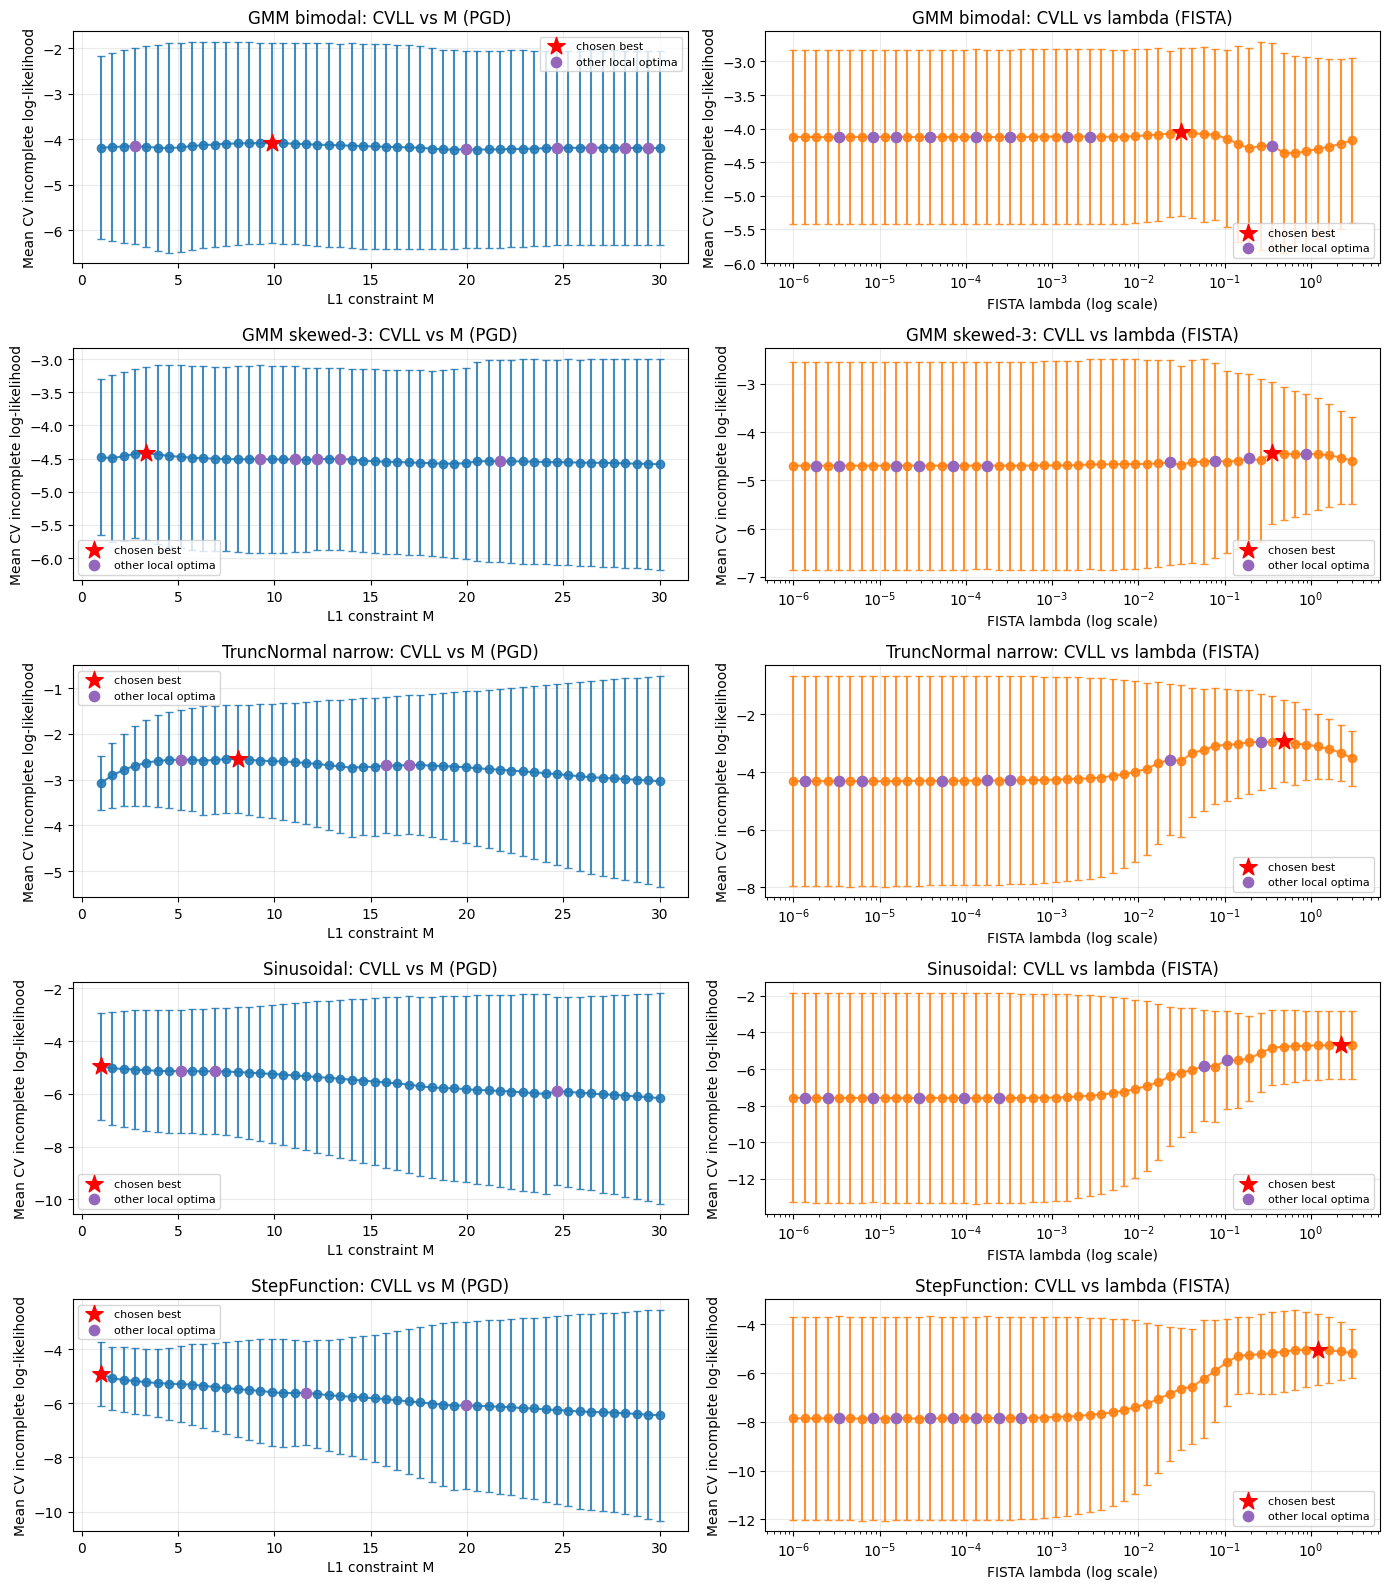

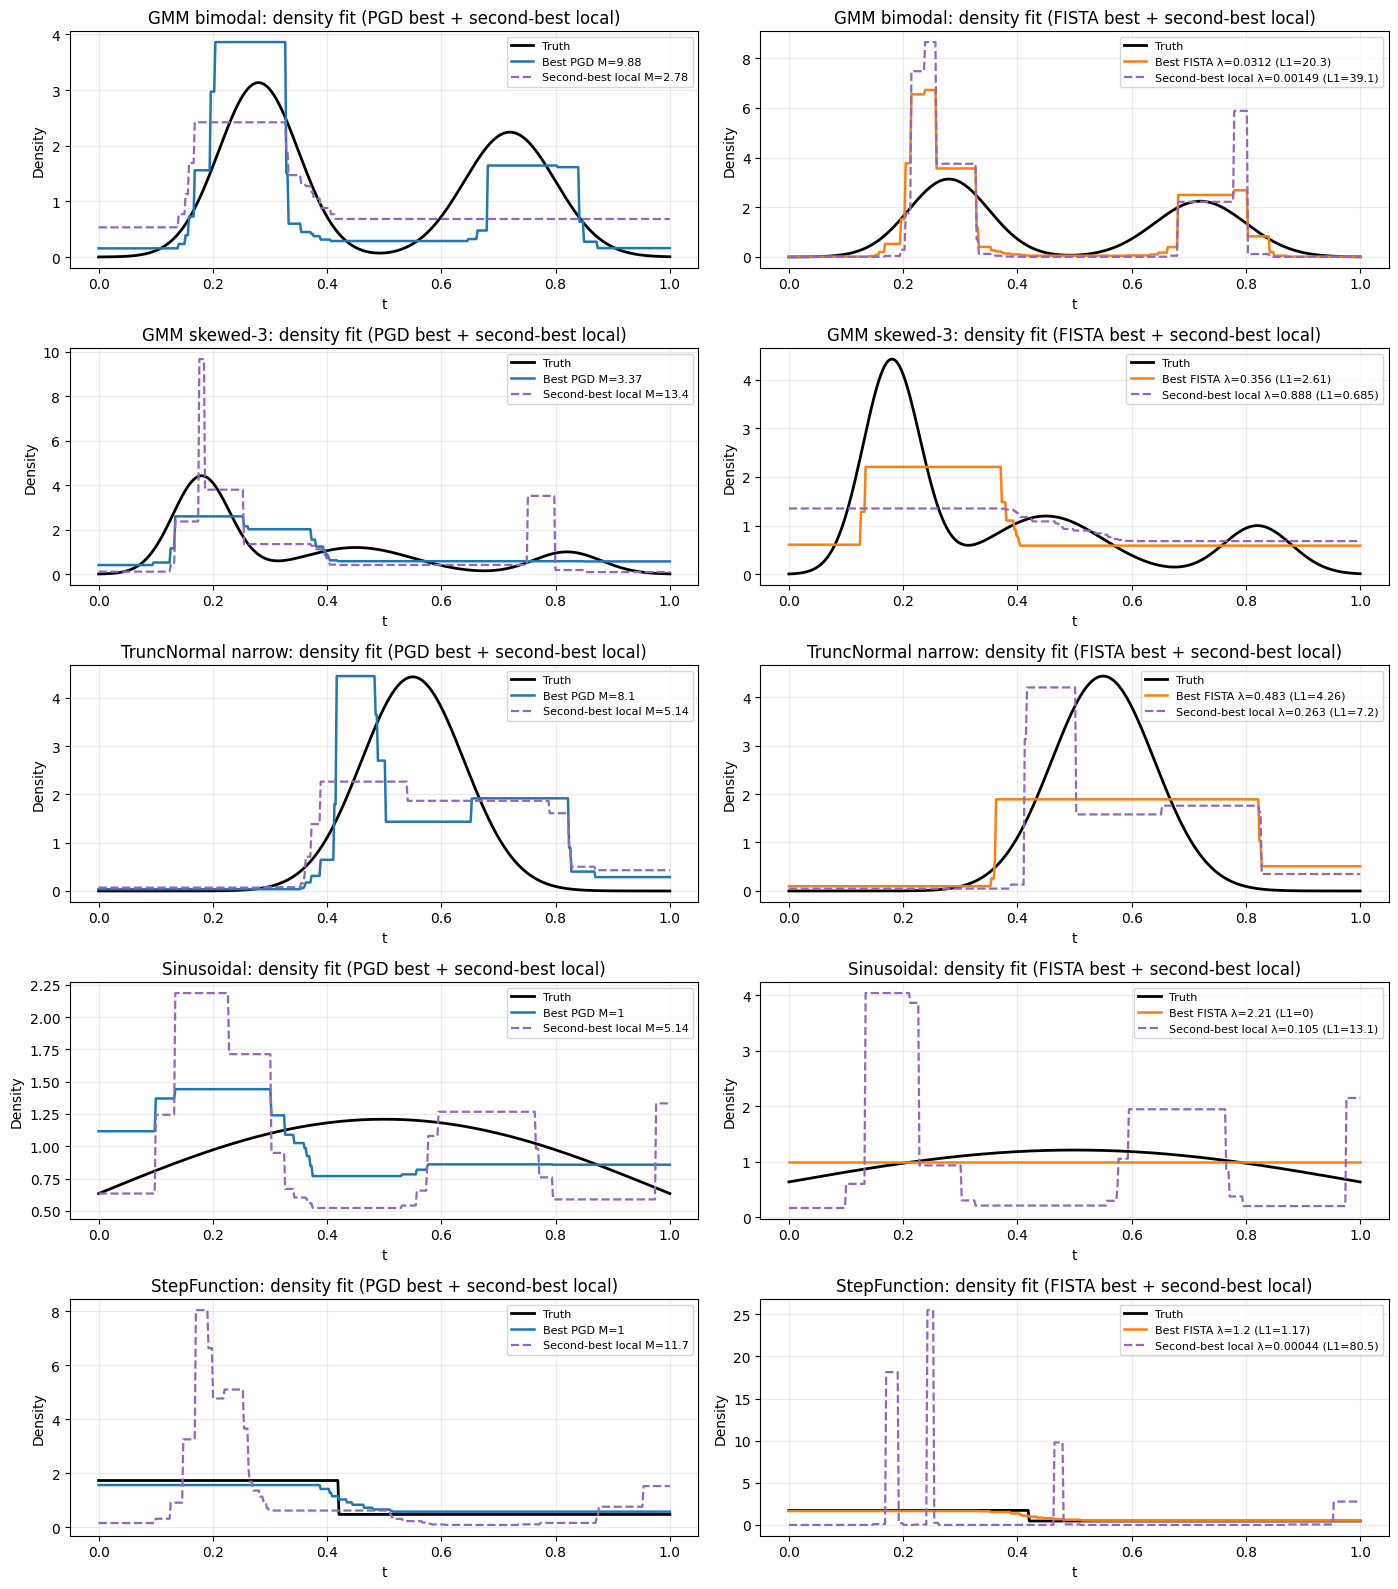

In [4]:
# ---- Plot 1: CVLL shapes (best + local optima highlighted) ----
fig, axes = plt.subplots(len(shape_results), 2, figsize=(14, 3.2 * len(shape_results)), squeeze=False)
summary_rows = []

for r, (name, out) in enumerate(shape_results.items()):
    m_df = out["M"]
    lam_df = out["lambda"]

    # CVLL vs M (PGD)
    ax_m = axes[r, 0]
    ax_m.errorbar(
        m_df["M"],
        m_df["cv_ll_mean"],
        yerr=m_df["cv_ll_sd"],
        fmt="o-",
        capsize=3,
        color="tab:blue",
        alpha=0.85,
    )
    i_best_m = out["best_idx_M"]
    ax_m.scatter(
        [m_df.iloc[i_best_m]["M"]],
        [m_df.iloc[i_best_m]["cv_ll_mean"]],
        color="red",
        marker="*",
        s=170,
        zorder=4,
        label="chosen best",
    )
    if out["local_idx_M"]:
        ax_m.scatter(
            m_df.iloc[out["local_idx_M"]]["M"],
            m_df.iloc[out["local_idx_M"]]["cv_ll_mean"],
            color="tab:purple",
            marker="o",
            s=55,
            zorder=4,
            label="other local optima",
        )
    ax_m.set_xlabel("L1 constraint M")
    ax_m.set_ylabel("Mean CV incomplete log-likelihood")
    ax_m.set_title(f"{name}: CVLL vs M (PGD)")
    ax_m.grid(alpha=0.25)
    ax_m.legend(fontsize=8)

    # CVLL vs lambda (FISTA)
    ax_l = axes[r, 1]
    ax_l.errorbar(
        lam_df["lambda"],
        lam_df["cv_ll_mean"],
        yerr=lam_df["cv_ll_sd"],
        fmt="o-",
        capsize=3,
        color="tab:orange",
        alpha=0.85,
    )
    i_best_l = out["best_idx_lambda"]
    ax_l.scatter(
        [lam_df.iloc[i_best_l]["lambda"]],
        [lam_df.iloc[i_best_l]["cv_ll_mean"]],
        color="red",
        marker="*",
        s=170,
        zorder=4,
        label="chosen best",
    )
    if out["local_idx_lambda"]:
        ax_l.scatter(
            lam_df.iloc[out["local_idx_lambda"]]["lambda"],
            lam_df.iloc[out["local_idx_lambda"]]["cv_ll_mean"],
            color="tab:purple",
            marker="o",
            s=55,
            zorder=4,
            label="other local optima",
        )
    ax_l.set_xscale("log")
    ax_l.set_xlabel("FISTA lambda (log scale)")
    ax_l.set_ylabel("Mean CV incomplete log-likelihood")
    ax_l.set_title(f"{name}: CVLL vs lambda (FISTA)")
    ax_l.grid(alpha=0.25)
    ax_l.legend(fontsize=8)

    summary_rows.append(
        {
            "DGP": name,
            "best_M": out["best_M"],
            "best_cvll_M": float(m_df.iloc[i_best_m]["cv_ll_mean"]),
            "local_optima_M": [float(m_df.iloc[i]["M"]) for i in out["local_idx_M"]],
            "second_best_local_M": float(out["adj_local_M"]) if np.isfinite(out["adj_local_M"]) else np.nan,
            "is_concave_M": bool(out["is_concave_M"]),
            "n_nonconcave_M": int(out["n_nonconcave_M"]),
            "max_second_diff_M": float(out["max_second_diff_M"]),
            "best_lambda": out["best_lambda"],
            "best_cvll_lambda": float(lam_df.iloc[i_best_l]["cv_ll_mean"]),
            "local_optima_lambda": [float(lam_df.iloc[i]["lambda"]) for i in out["local_idx_lambda"]],
            "second_best_local_lambda": float(out["adj_local_lambda"]) if np.isfinite(out["adj_local_lambda"]) else np.nan,
            "best_lambda_l1_norm": float(out["best_lambda_l1_norm"]),
            "adj_local_lambda_l1_norm": float(out["adj_local_lambda_l1_norm"]) if np.isfinite(out["adj_local_lambda_l1_norm"]) else np.nan,
            "is_concave_lambda": bool(out["is_concave_lambda"]),
            "n_nonconcave_lambda": int(out["n_nonconcave_lambda"]),
            "max_second_diff_lambda": float(out["max_second_diff_lambda"]),
        }
    )

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows)
summary_df

# Concavity report requested
concavity_report = summary_df[
    [
        "DGP",
        "is_concave_M",
        "n_nonconcave_M",
        "max_second_diff_M",
        "is_concave_lambda",
        "n_nonconcave_lambda",
        "max_second_diff_lambda",
    ]
]
concavity_report

# ---- Plot 2: fit plots (10 total = 5 DGP x 2 methods) ----
fig_fit, axes_fit = plt.subplots(len(shape_results), 2, figsize=(14, 3.2 * len(shape_results)), squeeze=False)

for r, (name, out) in enumerate(shape_results.items()):
    x = out["x_fit"]
    truth = out["truth_fit"]

    # PGD best fit
    axp = axes_fit[r, 0]
    axp.plot(x, truth, color="black", lw=2.0, label="Truth")
    axp.plot(x, out["pgd_best_fit"], color="tab:blue", lw=1.8, label=f"Best PGD M={out['best_M']:.3g}")
    if out["pgd_adj_local_fit"] is not None:
        axp.plot(
            x,
            out["pgd_adj_local_fit"],
            color="tab:purple",
            lw=1.6,
            ls="--",
            label=f"Second-best local M={out['adj_local_M']:.3g}",
        )
    axp.set_title(f"{name}: density fit (PGD best + second-best local)")
    axp.set_xlabel("t")
    axp.set_ylabel("Density")
    axp.grid(alpha=0.25)
    axp.legend(fontsize=8)

    # FISTA best fit
    axf = axes_fit[r, 1]
    axf.plot(x, truth, color="black", lw=2.0, label="Truth")
    axf.plot(
        x,
        out["fista_best_fit"],
        color="tab:orange",
        lw=1.8,
        label=f"Best FISTA λ={out['best_lambda']:.3g} (L1={out['best_lambda_l1_norm']:.3g})",
    )
    if out["fista_adj_local_fit"] is not None:
        axf.plot(
            x,
            out["fista_adj_local_fit"],
            color="tab:purple",
            lw=1.6,
            ls="--",
            label=(
                f"Second-best local λ={out['adj_local_lambda']:.3g} "
                f"(L1={out['adj_local_lambda_l1_norm']:.3g})"
            ),
        )
    axf.set_title(f"{name}: density fit (FISTA best + second-best local)")
    axf.set_xlabel("t")
    axf.set_ylabel("Density")
    axf.grid(alpha=0.25)
    axf.legend(fontsize=8)

plt.tight_layout()
plt.show()

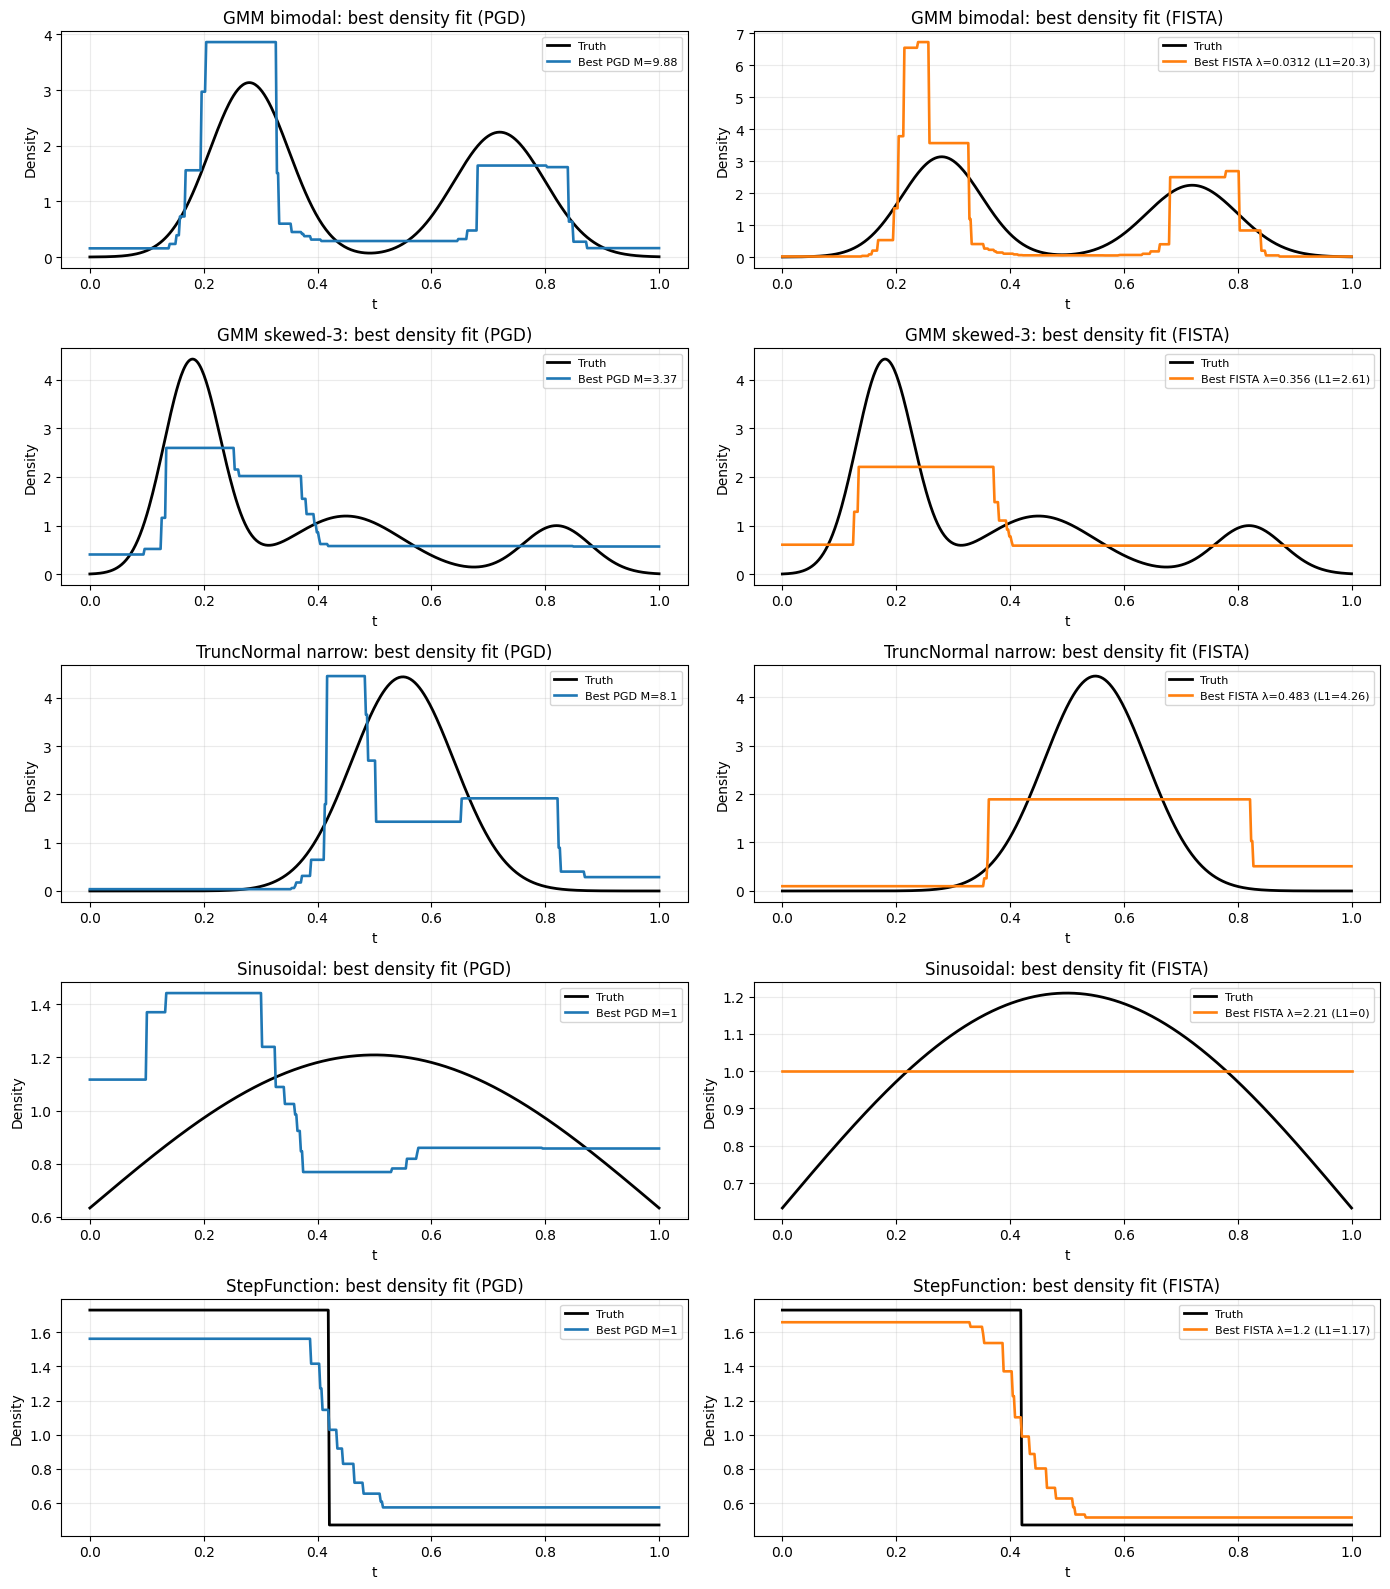

In [5]:
# ---- Plot 3: best-fit-only plots (10 total = 5 DGP x 2 methods) ----
fig_best, axes_best = plt.subplots(len(shape_results), 2, figsize=(14, 3.2 * len(shape_results)), squeeze=False)

for r, (name, out) in enumerate(shape_results.items()):
    x = out["x_fit"]
    truth = out["truth_fit"]

    # PGD best only
    axp = axes_best[r, 0]
    axp.plot(x, truth, color="black", lw=2.0, label="Truth")
    axp.plot(
        x,
        out["pgd_best_fit"],
        color="tab:blue",
        lw=1.9,
        label=f"Best PGD M={out['best_M']:.3g}",
    )
    axp.set_title(f"{name}: best density fit (PGD)")
    axp.set_xlabel("t")
    axp.set_ylabel("Density")
    axp.grid(alpha=0.25)
    axp.legend(fontsize=8)

    # FISTA best only
    axf = axes_best[r, 1]
    axf.plot(x, truth, color="black", lw=2.0, label="Truth")
    axf.plot(
        x,
        out["fista_best_fit"],
        color="tab:orange",
        lw=1.9,
        label=f"Best FISTA λ={out['best_lambda']:.3g} (L1={out['best_lambda_l1_norm']:.3g})",
    )
    axf.set_title(f"{name}: best density fit (FISTA)")
    axf.set_xlabel("t")
    axf.set_ylabel("Density")
    axf.grid(alpha=0.25)
    axf.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Sinusoidal DGP only: basis order 1 and 2

This chunk reruns the current-status analysis for the sinusoidal DGP using `basis_order = 1` and `basis_order = 2`, then compares:

- CVLL shape vs `M` (PGD)
- CVLL shape vs `lambda` (FISTA)
- best fitted densities vs truth

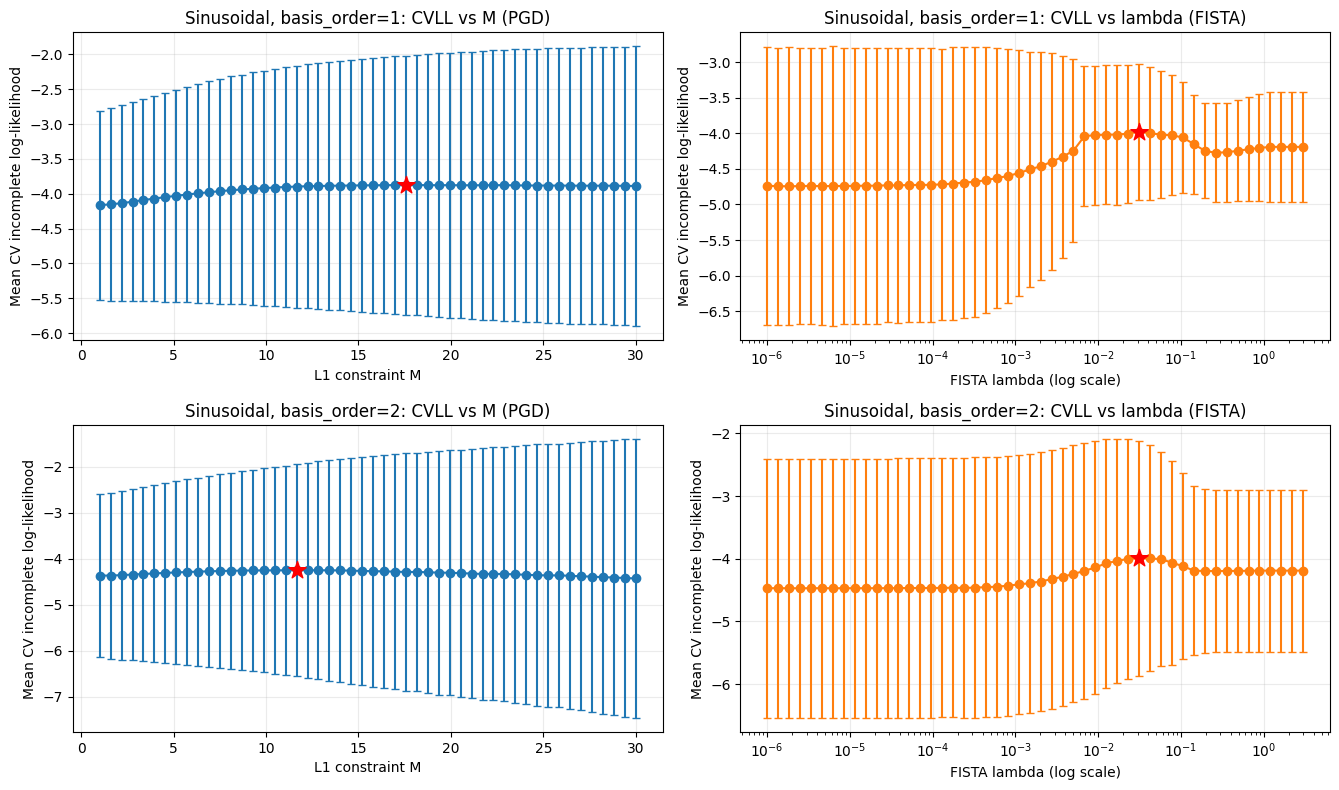

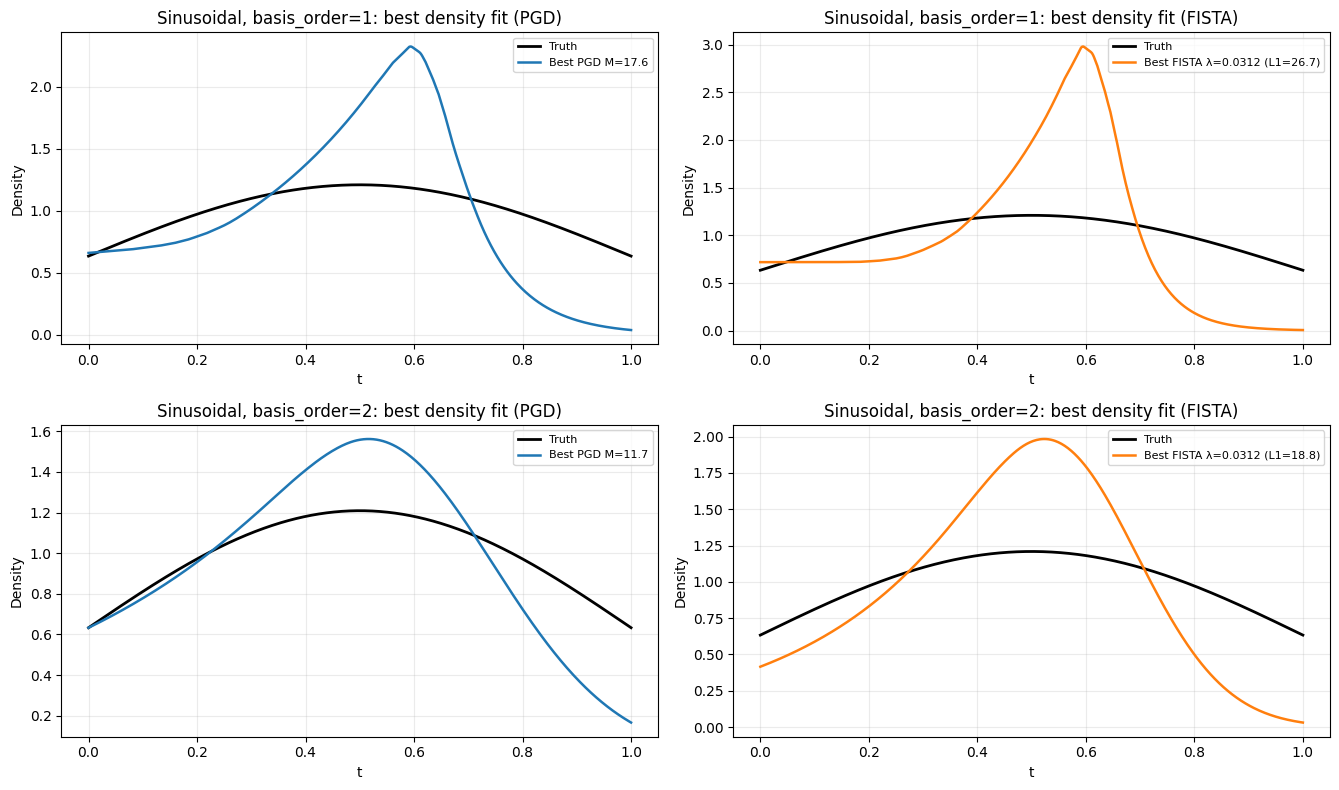

,basis_order,best_M,best_cvll_M,best_lambda,best_cvll_lambda,best_lambda_l1_norm
0,1,17.571429,-3.874870,0.031213,-3.977150,26.743568
1,2,11.653061,-4.248651,0.031213,-3.991328,18.772890


Order=2 largest one-step CVLL drop: -0.070036 from lambda=0.105 to lambda=0.143

Neighborhood diagnostics (includes convergence rate + mean iterations):


,lambda,cv_ll_mean,cv_ll_sd,conv_rate,iter_mean
36,0.057372,-4.007045,1.711865,1.0,41.4
37,0.077783,-4.062757,1.625482,1.0,49.2
38,0.105457,-4.119271,1.482165,1.0,44.0
39,0.142975,-4.189307,1.345984,1.0,28.6
40,0.193841,-4.196418,1.302670,1.0,17.0
41,0.262804,-4.195849,1.290745,1.0,6.4



Higher-iteration recheck on same fold split:


,lambda,cv_ll_mean_hi_iter,cv_ll_sd_hi_iter,conv_rate_hi_iter,iter_mean_hi_iter
0,0.057372,-4.007045,1.711865,1.0,41.4
1,0.077783,-4.062757,1.625482,1.0,49.2
2,0.105457,-4.119271,1.482165,1.0,44.0
3,0.142975,-4.189307,1.345984,1.0,28.6
4,0.193841,-4.196418,1.302670,1.0,17.0
5,0.262804,-4.195849,1.290745,1.0,6.4


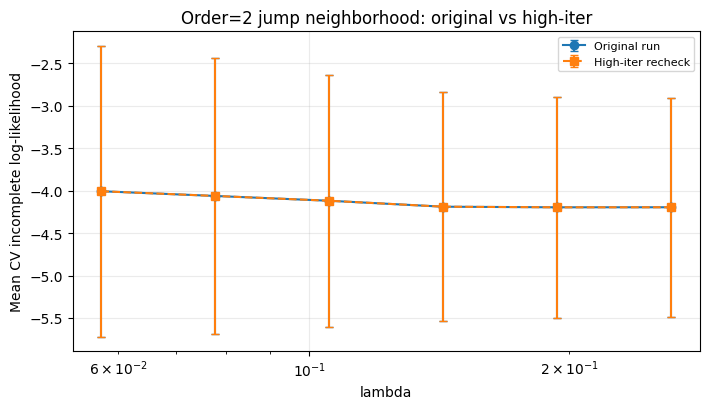

In [10]:
# Sinusoidal DGP: basis orders 1 and 2

sin_sampler = Sinusoidal()
sin_df = make_current_status_df(sin_sampler, n_samples=n, random_state=777)


def compute_shape_curve_ordered(
    df: pd.DataFrame,
    *,
    m_grid: np.ndarray,
    basis_order: int,
    random_state: int = 42,
    n_splits: int = 3,
) -> pd.DataFrame:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for M in m_grid:
        fold_ll = []
        for tr_idx, va_idx in kf.split(df):
            train_df = df.iloc[tr_idx].reset_index(drop=True)
            val_df = df.iloc[va_idx].reset_index(drop=True)

            est = IntervalCensoredProjectedGDEstimator(
                norm_constraint=float(M),
                basis_order=basis_order,
                learning_rate=0.05,
                use_nesterov=True,
                n_iterations=pgd_n_iterations,
                tol=1e-6,
                ll_change_tol=1e-4,
                n_grid_points=300,
            )
            est.fit(train_df, knot_strategy=knot_strategy)
            fold_ll.append(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

        rows.append(
            {
                "M": float(M),
                "cv_ll_mean": float(np.mean(fold_ll)),
                "cv_ll_sd": float(np.std(fold_ll, ddof=1)) if len(fold_ll) > 1 else 0.0,
            }
        )

    return pd.DataFrame(rows).sort_values("M").reset_index(drop=True)


def compute_lambda_curve_ordered(
    df: pd.DataFrame,
    *,
    lam_grid: np.ndarray,
    basis_order: int,
    random_state: int = 42,
    n_splits: int = 3,
) -> pd.DataFrame:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for lam in lam_grid:
        fold_ll = []
        fold_converged = []
        fold_iters = []

        for tr_idx, va_idx in kf.split(df):
            train_df = df.iloc[tr_idx].reset_index(drop=True)
            val_df = df.iloc[va_idx].reset_index(drop=True)

            est = IntervalCensoredFISTAEstimator(
                lam=float(lam),
                basis_order=basis_order,
                n_iterations=fista_n_iterations,
                tol=1e-6,
                ll_change_tol=1e-3,
                n_grid_points=300,
                initial_step=1.0,
                max_step=1.0,
            )
            est.fit(train_df, knot_strategy=knot_strategy)
            fold_ll.append(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

            res = est.get_results()
            fold_converged.append(bool(res.get("converged", False)))
            fold_iters.append(float(res.get("n_iterations_run", np.nan)))

        rows.append(
            {
                "lambda": float(lam),
                "cv_ll_mean": float(np.mean(fold_ll)),
                "cv_ll_sd": float(np.std(fold_ll, ddof=1)) if len(fold_ll) > 1 else 0.0,
                "conv_rate": float(np.mean(np.asarray(fold_converged, dtype=float))),
                "iter_mean": float(np.nanmean(fold_iters)),
            }
        )

    return pd.DataFrame(rows).sort_values("lambda").reset_index(drop=True)


sin_results = {}
for bo in [1, 2]:
    m_df = compute_shape_curve_ordered(
        sin_df,
        m_grid=M_grid,
        basis_order=bo,
        random_state=900 + 11 * bo,
        n_splits=n_folds,
    )
    lam_df = compute_lambda_curve_ordered(
        sin_df,
        lam_grid=lambda_grid,
        basis_order=bo,
        random_state=950 + 13 * bo,
        n_splits=n_folds,
    )

    i_best_m = int(np.nanargmax(m_df["cv_ll_mean"].to_numpy(dtype=float)))
    i_best_l = int(np.nanargmax(lam_df["cv_ll_mean"].to_numpy(dtype=float)))

    best_M = float(m_df.iloc[i_best_m]["M"])
    best_lambda = float(lam_df.iloc[i_best_l]["lambda"])

    est_pgd = IntervalCensoredProjectedGDEstimator(
        norm_constraint=best_M,
        basis_order=bo,
        learning_rate=0.05,
        use_nesterov=True,
        n_iterations=pgd_n_iterations,
        tol=1e-6,
        ll_change_tol=1e-4,
        n_grid_points=300,
    )
    est_pgd.fit(sin_df, knot_strategy=knot_strategy)

    est_fista = IntervalCensoredFISTAEstimator(
        lam=best_lambda,
        basis_order=bo,
        n_iterations=fista_n_iterations,
        tol=1e-6,
        ll_change_tol=1e-3,
        n_grid_points=300,
        initial_step=1.0,
        max_step=1.0,
    )
    est_fista.fit(sin_df, knot_strategy=knot_strategy)

    x_fit = np.linspace(0.0, 1.0, 500)
    truth = np.asarray(sin_sampler.compute_density(x_fit), dtype=float)

    sin_results[bo] = {
        "M": m_df,
        "lambda": lam_df,
        "best_M": best_M,
        "best_lambda": best_lambda,
        "best_lambda_l1_norm": _final_l1_norm(est_fista),
        "x_fit": x_fit,
        "truth": truth,
        "pgd_fit": np.asarray(est_pgd.get_density_at_points(x_fit), dtype=float),
        "fista_fit": np.asarray(est_fista.get_density_at_points(x_fit), dtype=float),
    }

# 1) CVLL shape plots
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8), squeeze=False)
for r, bo in enumerate([1, 2]):
    m_df = sin_results[bo]["M"]
    lam_df = sin_results[bo]["lambda"]

    axm = axes[r, 0]
    axm.errorbar(
        m_df["M"], m_df["cv_ll_mean"], yerr=m_df["cv_ll_sd"],
        fmt="o-", capsize=3, color="tab:blue"
    )
    axm.scatter([sin_results[bo]["best_M"]], [np.max(m_df["cv_ll_mean"])], color="red", marker="*", s=170, zorder=4)
    axm.set_xlabel("L1 constraint M")
    axm.set_ylabel("Mean CV incomplete log-likelihood")
    axm.set_title(f"Sinusoidal, basis_order={bo}: CVLL vs M (PGD)")
    axm.grid(alpha=0.25)

    axl = axes[r, 1]
    axl.errorbar(
        lam_df["lambda"], lam_df["cv_ll_mean"], yerr=lam_df["cv_ll_sd"],
        fmt="o-", capsize=3, color="tab:orange"
    )
    axl.scatter([sin_results[bo]["best_lambda"]], [np.max(lam_df["cv_ll_mean"])], color="red", marker="*", s=170, zorder=4)
    axl.set_xscale("log")
    axl.set_xlabel("FISTA lambda (log scale)")
    axl.set_ylabel("Mean CV incomplete log-likelihood")
    axl.set_title(f"Sinusoidal, basis_order={bo}: CVLL vs lambda (FISTA)")
    axl.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# 2) Best fit plots
fig2, axes2 = plt.subplots(2, 2, figsize=(13.5, 8), squeeze=False)
for r, bo in enumerate([1, 2]):
    x = sin_results[bo]["x_fit"]
    truth = sin_results[bo]["truth"]

    axp = axes2[r, 0]
    axp.plot(x, truth, color="black", lw=2.0, label="Truth")
    axp.plot(x, sin_results[bo]["pgd_fit"], color="tab:blue", lw=1.8, label=f"Best PGD M={sin_results[bo]['best_M']:.3g}")
    axp.set_title(f"Sinusoidal, basis_order={bo}: best density fit (PGD)")
    axp.set_xlabel("t")
    axp.set_ylabel("Density")
    axp.grid(alpha=0.25)
    axp.legend(fontsize=8)

    axf = axes2[r, 1]
    axf.plot(x, truth, color="black", lw=2.0, label="Truth")
    axf.plot(
        x,
        sin_results[bo]["fista_fit"],
        color="tab:orange",
        lw=1.8,
        label=(
            f"Best FISTA λ={sin_results[bo]['best_lambda']:.3g} "
            f"(L1={sin_results[bo]['best_lambda_l1_norm']:.3g})"
        ),
    )
    axf.set_title(f"Sinusoidal, basis_order={bo}: best density fit (FISTA)")
    axf.set_xlabel("t")
    axf.set_ylabel("Density")
    axf.grid(alpha=0.25)
    axf.legend(fontsize=8)

plt.tight_layout()
plt.show()

sin_summary_df = pd.DataFrame(
    [
        {
            "basis_order": bo,
            "best_M": sin_results[bo]["best_M"],
            "best_cvll_M": float(np.max(sin_results[bo]["M"]["cv_ll_mean"])),
            "best_lambda": sin_results[bo]["best_lambda"],
            "best_cvll_lambda": float(np.max(sin_results[bo]["lambda"]["cv_ll_mean"])),
            "best_lambda_l1_norm": sin_results[bo]["best_lambda_l1_norm"],
        }
        for bo in [1, 2]
    ]
)
display(sin_summary_df)

# --- Extra diagnostic for suspected order=2 jump point ---
lam_bo2 = sin_results[2]["lambda"].copy()
lam_bo2["delta_next"] = lam_bo2["cv_ll_mean"].shift(-1) - lam_bo2["cv_ll_mean"]

# Largest one-step drop on the evaluated grid
i_drop = int(np.nanargmin(lam_bo2["delta_next"].to_numpy(dtype=float)[:-1]))
lam_left = float(lam_bo2.iloc[i_drop]["lambda"])
lam_right = float(lam_bo2.iloc[i_drop + 1]["lambda"])

print(
    f"Order=2 largest one-step CVLL drop: {lam_bo2.iloc[i_drop]['delta_next']:.6f} "
    f"from lambda={lam_left:.3g} to lambda={lam_right:.3g}"
)

# Local neighborhood report around the drop
i0 = max(0, i_drop - 2)
i1 = min(len(lam_bo2), i_drop + 4)
print("\nNeighborhood diagnostics (includes convergence rate + mean iterations):")
display(lam_bo2.iloc[i0:i1][["lambda", "cv_ll_mean", "cv_ll_sd", "conv_rate", "iter_mean"]])

# Re-run just these lambdas with higher iteration budget to test optimization artifact
lam_focus = lam_bo2.iloc[i0:i1]["lambda"].to_numpy(dtype=float)

def _recheck_lambda(df: pd.DataFrame, lam: float, basis_order: int, rs: int, n_splits: int = 5) -> dict:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=rs)
    vals = []
    conv = []
    iters = []
    for tr_idx, va_idx in kf.split(df):
        train_df = df.iloc[tr_idx].reset_index(drop=True)
        val_df = df.iloc[va_idx].reset_index(drop=True)
        est = IntervalCensoredFISTAEstimator(
            lam=float(lam),
            basis_order=basis_order,
            n_iterations=max(6000, fista_n_iterations),
            tol=1e-6,
            ll_change_tol=1e-3,
            n_grid_points=300,
            initial_step=1.0,
            max_step=1.0,
        )
        est.fit(train_df, knot_strategy=knot_strategy)
        vals.append(float(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R")))
        r = est.get_results()
        conv.append(bool(r.get("converged", False)))
        iters.append(float(r.get("n_iterations_run", np.nan)))
    return {
        "lambda": float(lam),
        "cv_ll_mean_hi_iter": float(np.mean(vals)),
        "cv_ll_sd_hi_iter": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        "conv_rate_hi_iter": float(np.mean(np.asarray(conv, dtype=float))),
        "iter_mean_hi_iter": float(np.nanmean(iters)),
    }

recheck_df = pd.DataFrame(
    [_recheck_lambda(sin_df, lam, basis_order=2, rs=950 + 13 * 2, n_splits=n_folds) for lam in lam_focus]
)

print("\nHigher-iteration recheck on same fold split:")
display(recheck_df)

# Optional visual compare original vs high-iter in the neighborhood
figd, axd = plt.subplots(1, 1, figsize=(7.2, 4.2))
axd.errorbar(
    lam_bo2.iloc[i0:i1]["lambda"],
    lam_bo2.iloc[i0:i1]["cv_ll_mean"],
    yerr=lam_bo2.iloc[i0:i1]["cv_ll_sd"],
    fmt="o-",
    capsize=3,
    label="Original run",
)
axd.errorbar(
    recheck_df["lambda"],
    recheck_df["cv_ll_mean_hi_iter"],
    yerr=recheck_df["cv_ll_sd_hi_iter"],
    fmt="s--",
    capsize=3,
    label="High-iter recheck",
)
axd.set_xscale("log")
axd.set_xlabel("lambda")
axd.set_ylabel("Mean CV incomplete log-likelihood")
axd.set_title("Order=2 jump neighborhood: original vs high-iter")
axd.grid(alpha=0.25)
axd.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Diagnostic: order=2 FISTA dip near `1e-4` to `1e-3`

This section inspects the sudden CVLL dip by checking fold-level behavior and optimization diagnostics for nearby lambda values.

Mean-row diagnostics (converged is fold convergence rate in [0,1]):


,lambda,fold,cv_ll,converged,n_iterations_run,fitted_l1,n_selected_knots
0,0.000100,mean,-4.740517,0.6,718.4,610.256920,40.0
1,0.000133,mean,-4.722083,0.6,716.8,580.322655,39.8
2,0.000178,mean,-4.697758,0.6,712.4,541.312139,39.2
3,0.000237,mean,-6.775713,0.6,935.2,934.014872,36.8
4,0.000316,mean,-4.662214,0.8,683.0,435.390598,38.0
5,0.000422,mean,-4.637123,0.8,615.8,365.099150,38.0
6,0.000562,mean,-4.603799,0.8,575.8,319.472213,36.0
7,0.000750,mean,-4.544620,1.0,359.8,273.339924,37.4
8,0.001000,mean,-5.305623,1.0,485.4,408.926505,33.6


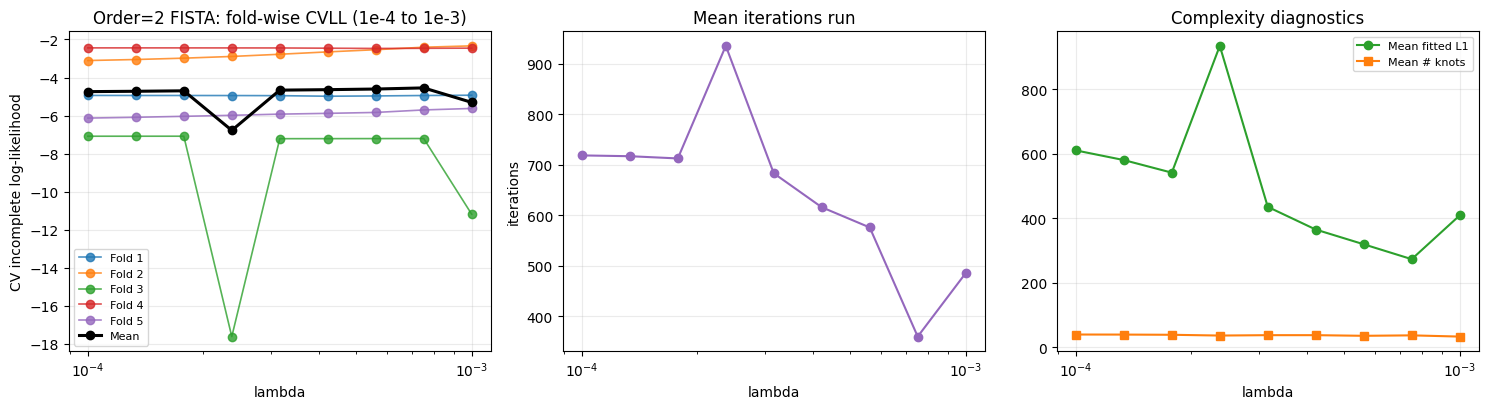

Largest one-step mean CVLL drop in interval: -2.077954 from lambda=0.000178 to 0.000237


In [7]:
# Focused diagnostics for the observed dip region (basis_order=2, FISTA)

bo_dbg = 2
lam_dbg_grid = np.geomspace(1e-4, 1e-3, 9)

# Use same fold protocol as the main run for consistency
kf_dbg = KFold(n_splits=n_folds, shuffle=True, random_state=950 + 13 * bo_dbg)

rows_dbg = []
for lam in lam_dbg_grid:
    fold_ll = []
    fold_conv = []
    fold_iter = []
    fold_l1 = []
    fold_knots = []

    for fold_id, (tr_idx, va_idx) in enumerate(kf_dbg.split(sin_df), start=1):
        train_df = sin_df.iloc[tr_idx].reset_index(drop=True)
        val_df = sin_df.iloc[va_idx].reset_index(drop=True)

        est = IntervalCensoredFISTAEstimator(
            lam=float(lam),
            basis_order=bo_dbg,
            n_iterations=fista_n_iterations,
            tol=1e-6,
            ll_change_tol=1e-4,
            n_grid_points=300,
            initial_step=1.0,
            max_step=1.0,
            history_every=100,
        )
        est.fit(train_df, knot_strategy=knot_strategy)
        ll = float(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

        res = est.get_results()
        fold_ll.append(ll)
        fold_conv.append(bool(res.get("converged", False)))
        fold_iter.append(int(res.get("n_iterations_run", np.nan)))
        fold_l1.append(_final_l1_norm(est))
        fold_knots.append(float(res.get("n_selected_knots", np.nan)))

        rows_dbg.append(
            {
                "lambda": float(lam),
                "fold": fold_id,
                "cv_ll": ll,
                "converged": bool(res.get("converged", False)),
                "n_iterations_run": int(res.get("n_iterations_run", np.nan)),
                "fitted_l1": _final_l1_norm(est),
                "n_selected_knots": float(res.get("n_selected_knots", np.nan)),
            }
        )

    rows_dbg.append(
        {
            "lambda": float(lam),
            "fold": "mean",
            "cv_ll": float(np.mean(fold_ll)),
            "converged": float(np.mean(np.asarray(fold_conv, dtype=float))),
            "n_iterations_run": float(np.mean(fold_iter)),
            "fitted_l1": float(np.mean(fold_l1)),
            "n_selected_knots": float(np.mean(fold_knots)),
        }
    )

diag_df = pd.DataFrame(rows_dbg)
fold_df = diag_df[diag_df["fold"] != "mean"].copy()
mean_df = diag_df[diag_df["fold"] == "mean"].copy().sort_values("lambda").reset_index(drop=True)

print("Mean-row diagnostics (converged is fold convergence rate in [0,1]):")
display(mean_df)

# Plot fold-wise CVLL traces and mean trend in the suspect interval
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for fold_id in sorted(fold_df["fold"].unique()):
    f = fold_df[fold_df["fold"] == fold_id].sort_values("lambda")
    axes[0].plot(f["lambda"], f["cv_ll"], marker="o", lw=1.2, alpha=0.8, label=f"Fold {fold_id}")
axes[0].plot(mean_df["lambda"], mean_df["cv_ll"], color="black", lw=2.2, marker="o", label="Mean")
axes[0].set_xscale("log")
axes[0].set_title("Order=2 FISTA: fold-wise CVLL (1e-4 to 1e-3)")
axes[0].set_xlabel("lambda")
axes[0].set_ylabel("CV incomplete log-likelihood")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(mean_df["lambda"], mean_df["n_iterations_run"], marker="o", color="tab:purple")
axes[1].set_xscale("log")
axes[1].set_title("Mean iterations run")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("iterations")
axes[1].grid(alpha=0.25)

axes[2].plot(mean_df["lambda"], mean_df["fitted_l1"], marker="o", color="tab:green", label="Mean fitted L1")
axes[2].plot(mean_df["lambda"], mean_df["n_selected_knots"], marker="s", color="tab:orange", label="Mean # knots")
axes[2].set_xscale("log")
axes[2].set_title("Complexity diagnostics")
axes[2].set_xlabel("lambda")
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Quick textual flag: where largest drop occurs in this interval
cv_vals = mean_df["cv_ll"].to_numpy(dtype=float)
if len(cv_vals) >= 2:
    d = np.diff(cv_vals)
    i_drop = int(np.argmin(d))
    print(
        f"Largest one-step mean CVLL drop in interval: {d[i_drop]:.6f} "
        f"from lambda={mean_df.iloc[i_drop]['lambda']:.3g} to {mean_df.iloc[i_drop + 1]['lambda']:.3g}"
    )